## Athens UF PM campaign at NOA Jan-Feb 2025

In [32]:
# Install packages
!pip install pandas openpyxl matplotlib python-pptx seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
# Install libraries
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
import io
import matplotlib.ticker as ticker
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN
import seaborn as sns

In [3]:
# Define working directories
wdir = Path("C:/Users/GeorgiaRg/Documents/Athens2025/Python_analysis")
os.chdir(wdir) # Change directory
output_dir = "C:/Users/GeorgiaRg/Documents/Athens2025/Python_analysis/output" # Define the name or path of your output folder
os.makedirs(output_dir, exist_ok=True) # exist_ok=True prevents an error if you run this cell multiple times

## Import NOA data

In [4]:
df_noa_1 = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/NOA data/UF PM Campaign (Athens-Thissio 2025).xlsx", sheet_name="hourly data")
df_noa_2 = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/NOA data/UF PM Campaign (Athens-Thissio 2025).xlsx", sheet_name="BC")
df_noa_3 = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/NOA data/Th_ACSM_PMF_Jan_Feb25.xlsx", sheet_name="ACSM_raw")
df_noa_4 = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/NOA data/Th_ACSM_PMF_Jan_Feb25.xlsx", sheet_name="PMF_raw")
#ptrms noa
#df_noa_5 = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/NOA data/Thissio_ambient_11sec_clean_winter_campaign.xlsx", sheet_name="Thissio_ambient_11sec")

# Prep function for data that is ALREADY hourly
def prep_hourly_data(df, time_col_name):
    if time_col_name not in df.columns:
        raise ValueError(f"Column '{time_col_name}' not found. Please check your Excel headers.")
    df = df.copy()
    df['Datetime'] = pd.to_datetime(df[time_col_name]).dt.round('h')
    df = df.set_index('Datetime')
    df_numeric = df.select_dtypes(include='number')

    return df_numeric

# Prep function for RAW data that needs averaging
def make_hourly_averages(df, time_col_name):
    if time_col_name not in df.columns:
        raise ValueError(f"Column '{time_col_name}' not found. Please check your Excel headers.")
    df = df.copy()
    df['Datetime'] = pd.to_datetime(df[time_col_name])

    df = df.set_index('Datetime')
    df_numeric = df.select_dtypes(include='number')
    df_hourly = df_numeric.resample('h').mean()

    return df_hourly

# These are already hourly, so we just prep them
hourly_noa_1 = prep_hourly_data(df_noa_1, time_col_name="DateTime")
hourly_noa_2 = prep_hourly_data(df_noa_2, time_col_name="DateTime")
# These are raw, so we average them
hourly_noa_3 = make_hourly_averages(df_noa_3, time_col_name="DateTime")
hourly_noa_4 = make_hourly_averages(df_noa_4, time_col_name="DateTime")

df_noa_all = pd.concat([hourly_noa_1, hourly_noa_2, hourly_noa_3, hourly_noa_4], axis=1, sort=False) # Merge them all together
df_noa_all = df_noa_all.reset_index() # Clean up: Move Datetime from the index back to a normal column
df_noa_all['Datetime'] = df_noa_all['Datetime'].dt.round('h') # Round the Datetime column to the nearest exact hour
df_noa_all = df_noa_all.groupby('Datetime').mean().reset_index() # Group the data by this perfectly rounded hour and combine the rows

In [5]:
df_noa_all # Display the final dataframe

,Datetime,O3 (μg/m3),CO (mg/m3),CO2 (mg/m3),CH4 (mg/m3),NO (μg/m3),NO2 (μg/m3),PM2.5 (μg/m3) _ GRIMM,PM2.5 (μg/m3) _ Beta 5014i,Air Temperature (°C),...,NO3_prcor_CE (μgm-3),SO4_prcor_CE (μgm-3),NH4_prcor_CE (μgm-3),Cl_prcor_CE (μgm-3),HOA (μgm-3),COA (μgm-3),BBOA (μgm-3),LOOOA (μgm-3),MOOOA (μgm-3),OOA (μgm-3)
0,2025-01-20 00:00:00,10.589460,0.848844,841.027612,1.411365,3.506980,52.415249,41.071667,34.345500,9.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-20 01:00:00,11.221875,0.771616,841.329009,1.410319,2.481738,50.800565,33.593333,35.005833,9.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-20 02:00:00,34.788810,0.479883,818.951527,1.392298,0.656546,33.121576,22.811667,25.262833,8.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-20 03:00:00,35.615073,0.416095,821.641006,1.417040,0.311750,28.133168,20.848333,20.133833,8.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-20 04:00:00,40.030007,0.340457,816.457439,1.396274,0.311750,29.320520,12.846667,16.415500,8.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
787,2025-02-21 19:00:00,75.985227,0.303786,806.931473,1.354379,0.311750,17.577653,18.650000,15.393500,5.1,...,0.639171,2.881984,0.788876,0.108893,0.612658,1.405380,0.900534,2.425590,1.506257,3.931847
788,2025-02-21 20:00:00,77.633430,0.302497,806.619900,1.353687,0.311750,17.851707,18.750000,15.843167,4.7,...,0.607114,3.219981,1.001194,0.163411,0.836702,2.225156,0.954701,2.648562,1.785074,4.433636
789,2025-02-21 21:00:00,77.888125,0.303669,805.189148,1.354049,0.311750,17.552797,18.978333,16.798667,4.6,...,0.495719,2.281856,0.512058,0.098816,1.253524,2.027012,1.045286,2.328956,1.211315,3.540270
790,2025-02-21 22:00:00,80.615955,0.299266,800.840863,1.351632,0.311750,15.483695,16.350000,17.496667,4.8,...,0.481993,2.024620,0.415472,0.087619,0.653359,1.093623,0.954549,1.904947,0.987239,2.892186


In [6]:
#Change O3, NO, NO2 to ppb and CO, CO2 and CH4 to ppm
df_noa_all_original = df_noa_all #keep original dataframe with gases in mg/m3 and μg/m3

# At 25°C and 1 atm, Vm = 24.45 L/mol.
Vm = 24.45
# Molecular Weights (g/mol) for each gas
mw = {
    'O3': 48.00,
    'NO': 30.01,
    'NO2': 46.01,
    'CO': 28.01,
    'CO2': 44.01,
    'CH4': 16.04
}

# Convert µg/m3 to ppb using Formula: ppb = (µg/m3) * (Vm / MW)
df_noa_all['O3 (μg/m3)'] = df_noa_all['O3 (μg/m3)'] * (Vm / mw['O3'])
df_noa_all['NO (μg/m3)'] = df_noa_all['NO (μg/m3)'] * (Vm / mw['NO'])
df_noa_all['NO2 (μg/m3)'] = df_noa_all['NO2 (μg/m3)'] * (Vm / mw['NO2'])

# Convert mg/m3 to ppm using Formula: ppm = (mg/m3) * (Vm / MW)
df_noa_all['CO (mg/m3)'] = df_noa_all['CO (mg/m3)'] * (Vm / mw['CO'])
df_noa_all['CO2 (mg/m3)'] = df_noa_all['CO2 (mg/m3)'] * (Vm / mw['CO2'])
df_noa_all['CH4 (mg/m3)'] = df_noa_all['CH4 (mg/m3)'] * (Vm / mw['CH4'])

# Rename the columns to reflect the new units
df_noa_all = df_noa_all.rename(columns={
    'O3 (μg/m3)': 'O3 (ppb)',
    'NO (μg/m3)': 'NO (ppb)',
    'NO2 (μg/m3)': 'NO2 (ppb)',
    'CO (mg/m3)': 'CO (ppm)',
    'CO2 (mg/m3)': 'CO2 (ppm)',
    'CH4 (mg/m3)': 'CH4 (ppm)'
})

df_noa_all

,Datetime,O3 (ppb),CO (ppm),CO2 (ppm),CH4 (ppm),NO (ppb),NO2 (ppb),PM2.5 (μg/m3) _ GRIMM,PM2.5 (μg/m3) _ Beta 5014i,Air Temperature (°C),...,NO3_prcor_CE (μgm-3),SO4_prcor_CE (μgm-3),NH4_prcor_CE (μgm-3),Cl_prcor_CE (μgm-3),HOA (μgm-3),COA (μgm-3),BBOA (μgm-3),LOOOA (μgm-3),MOOOA (μgm-3),OOA (μgm-3)
0,2025-01-20 00:00:00,5.394006,0.740958,467.237562,2.151364,2.857236,27.853789,41.071667,34.345500,9.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-20 01:00:00,5.716143,0.673546,467.405005,2.149769,2.021942,26.995736,33.593333,35.005833,9.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-20 02:00:00,17.720550,0.418891,454.973070,2.122300,0.534906,17.601011,22.811667,25.262833,8.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-20 03:00:00,18.141428,0.363210,456.467225,2.160014,0.253992,14.950140,20.848333,20.133833,8.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-20 04:00:00,20.390285,0.297186,453.587466,2.128360,0.253992,15.581107,12.846667,16.415500,8.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
787,2025-02-21 19:00:00,38.704975,0.265176,448.295263,2.064498,0.253992,9.340874,18.650000,15.393500,5.1,...,0.639171,2.881984,0.788876,0.108893,0.612658,1.405380,0.900534,2.425590,1.506257,3.931847
788,2025-02-21 20:00:00,39.544528,0.264050,448.122166,2.063445,0.253992,9.486508,18.750000,15.843167,4.7,...,0.607114,3.219981,1.001194,0.163411,0.836702,2.225156,0.954701,2.648562,1.785074,4.433636
789,2025-02-21 21:00:00,39.674264,0.265074,447.327304,2.063996,0.253992,9.327666,18.978333,16.798667,4.6,...,0.495719,2.281856,0.512058,0.098816,1.253524,2.027012,1.045286,2.328956,1.211315,3.540270
790,2025-02-21 22:00:00,41.063752,0.261230,444.911590,2.060311,0.253992,8.228132,16.350000,17.496667,4.8,...,0.481993,2.024620,0.415472,0.087619,0.653359,1.093623,0.954549,1.904947,0.987239,2.892186


In [69]:
df_noa_all.columns

Index(['Datetime', 'O3 (ppb)', 'CO (ppm)', 'CO2 (ppm)', 'CH4 (ppm)',
       'NO (ppb)', 'NO2 (ppb)', 'PM2.5 (μg/m3) _ GRIMM',
       'PM2.5 (μg/m3) _ Beta 5014i', 'Air Temperature (°C)', 'RH (%)',
       'Pressure (hPa)', 'Rainfall (mm)', 'SR (W/m2)', 'Speed (m/s)',
       'Wind Dir (°)', 'BC (μg m3)', 'BCbb (μg m3)', 'BCff (μg m3)',
       'Org_prcor_CE (μgm-3)', 'NO3_prcor_CE (μgm-3)', 'SO4_prcor_CE (μgm-3)',
       'NH4_prcor_CE (μgm-3)', 'Cl_prcor_CE (μgm-3)', 'HOA (μgm-3)',
       'COA (μgm-3)', 'BBOA (μgm-3)', 'LOOOA (μgm-3)', 'MOOOA (μgm-3)',
       'OOA (μgm-3)'],
      dtype='str')

## Import our data

In [7]:
df_so2 = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/SO2/SO2_hourly.xlsx", sheet_name="SO2")
df_so2

,date,SO2
0,2025-01-21 13:00:00,1.584460
1,2025-01-21 14:00:00,1.028468
2,2025-01-21 15:00:00,0.863088
3,2025-01-21 16:00:00,0.905154
4,2025-01-21 17:00:00,0.948995
...,...,...
712,2025-02-20 05:00:00,0.170343
713,2025-02-20 06:00:00,0.201643
714,2025-02-20 07:00:00,0.214137
715,2025-02-20 08:00:00,0.216168


In [8]:
#sp2xr, measuring BC PM0.1, 1h averaged and dilution corrected
df_sp2_all = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/SP2/data_for_processing/hourly_rBC.xlsx", sheet_name="Sheet 1")
df_sp2 = df_sp2_all[['date', 'DILUTION_corr_Incand.Mass.Conc.μg.m3.']].rename(columns={'DILUTION_corr_Incand.Mass.Conc.μg.m3.': 'bc_pm0.1'})

df_sp2

,date,bc_pm0.1
0,2025-01-23 11:00:00,0.084106
1,2025-01-23 12:00:00,0.031685
2,2025-01-23 13:00:00,0.026074
3,2025-01-23 14:00:00,0.028166
4,2025-01-23 15:00:00,0.048985
...,...,...
690,2025-02-21 05:00:00,0.018451
691,2025-02-21 06:00:00,0.042793
692,2025-02-21 07:00:00,0.069698
693,2025-02-21 08:00:00,0.063997


In [88]:
# SMPSs and CPC50
df_smps_van_dm = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/SMPSs/SMPSs.xlsx", sheet_name="SMPS3034_dM")
df_smps_van_dmdlogdp = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/SMPSs/SMPSs.xlsx", sheet_name="SMPS3034_dMdlogDp")
df_smps_van_dndlogdp = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/SMPSs/SMPSs.xlsx", sheet_name="SMPS3034_dNdlogDp")
df_smps_noa_dm = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/SMPSs/SMPSs.xlsx", sheet_name="SMPSregular_dM")
df_smps_noa_dmdlogdp = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/SMPSs/SMPSs.xlsx", sheet_name="SMPSregular_dMdlogDp")
df_smps_noa_dndlogdp = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/SMPSs/SMPSs.xlsx", sheet_name="SMPSregular_dNdlogDp")
df_cpc50 = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/SMPSs/SMPSs.xlsx", sheet_name="CPC50")

In [89]:
# Define the start and end of the troubleshooting period
troubleshooting_start = '2025-02-07 00:00:00'
troubleshooting_end = '2025-02-10 23:59:59'

# Create a helper function to clean any dataframe based on its DateTime column
def remove_troubleshooting_data(df, start_date, end_date, time_col='DateTime'):
    df_clean = df.copy()
    # Ensure the column is explicitly recognized as datetime for accurate filtering
    df_clean[time_col] = pd.to_datetime(df_clean[time_col])

    # Create the mask for the bad data window
    bad_data_mask = (df_clean[time_col] >= start_date) & (df_clean[time_col] <= end_date)

    # Keep only the rows that are NOT in the bad data mask
    return df_clean[~bad_data_mask]

# Apply the cleaning function to the three original raw NOA datasets
df_smps_noa_dm = remove_troubleshooting_data(df_smps_noa_dm, troubleshooting_start, troubleshooting_end)
df_smps_noa_dmdlogdp = remove_troubleshooting_data(df_smps_noa_dmdlogdp, troubleshooting_start, troubleshooting_end)
df_smps_noa_dndlogdp = remove_troubleshooting_data(df_smps_noa_dndlogdp, troubleshooting_start, troubleshooting_end)

print(f"Successfully removed troubleshooting data ({troubleshooting_start} to {troubleshooting_end}) from raw NOA datasets.")

Successfully removed troubleshooting data (2025-02-07 00:00:00 to 2025-02-10 23:59:59) from raw NOA datasets.


In [11]:
#AMS - PM0.1 [in the van, after the AAC, 3min samples]
df_ams_species = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/AMS/Preliminary_timeseries.xlsx", sheet_name="species_forR_neg")
df_ams_factors = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/AMS/Preliminary_timeseries.xlsx", sheet_name="factors_forR")

In [12]:
#Xact - PM0.1
df_xact_corr = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/Xact/Processed_data_Athens.xlsx", sheet_name="corrected")  #dilution and blank corrected [based on 2 field blank measurements, n=1]
#df_xact_diagnostics = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/Xact/Processed_data_Athens.xlsx", sheet_name="diagnostics")
#df_xact_qa = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/Xact/Processed_data_Athens.xlsx", sheet_name="QAs")

In [13]:
# Our PM2.5 Thermo monitor that was in the Van
data_dir = Path(r"C:/Users/GeorgiaRg/Documents/Athens2025/PM2.5 monitor_van")
dfs = []
for file_path in data_dir.glob("*.dat"):
    df = pd.read_csv(file_path, sep=r'\s+', comment=';')
    dfs.append(df)
df_pm25 = pd.concat(dfs, ignore_index=True)
df_pm25['Datetime'] = pd.to_datetime(df_pm25['Date'] + ' ' + df_pm25['Time'], format='%m-%d-%y %H:%M')
df_pm25 = df_pm25.drop_duplicates(subset=['Datetime'], keep='first')
df_pm25 = df_pm25.sort_values(by='Datetime').reset_index(drop=True)
df_pm25 = df_pm25.drop(columns=['Date', 'Time'])
df_pm25 = df_pm25[['Datetime', 'pm']]  #keep only datetime and pm2.5 values
df_pm25['pm'] = pd.to_numeric(df_pm25['pm'], errors='coerce')
df_pm25_clean = df_pm25
df_pm25_clean['pm'] = df_pm25['pm'].clip(lower=0)  #replace negative values with 0

df_pm25_clean_hourly = df_pm25_clean.resample('h', on='Datetime').mean()
df_pm25_clean_hourly = df_pm25_clean_hourly.reset_index()
#output_file = data_dir / "PM25_Hourly_Averages.xlsx"     #for excel file output of the hourly pm2.5
#df_pm25_clean_hourly.to_excel(output_file, index=False)

df_pm25_clean_hourly

,Datetime,pm
0,2025-01-09 14:00:00,0.000000
1,2025-01-09 15:00:00,0.022761
2,2025-01-09 16:00:00,0.668468
3,2025-01-09 17:00:00,NaN
4,2025-01-09 18:00:00,NaN
...,...,...
1023,2025-02-21 05:00:00,7.405101
1024,2025-02-21 06:00:00,11.482947
1025,2025-02-21 07:00:00,10.001822
1026,2025-02-21 08:00:00,9.734248


## PM2.5 Metals Demokritos

In [14]:
#PM2.5- HVS - quartz filters -WDXRF analysis
df_metals_pm25 = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/Xact/Metals from Demokritos/PM2.5_Metals_WD-XRF.xlsx", sheet_name="concentrations")
df_metals_pm25_LOD = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/Xact/Metals from Demokritos/PM2.5_Metals_WD-XRF.xlsx", sheet_name="LOD")

## Pseudo 3D size distributions

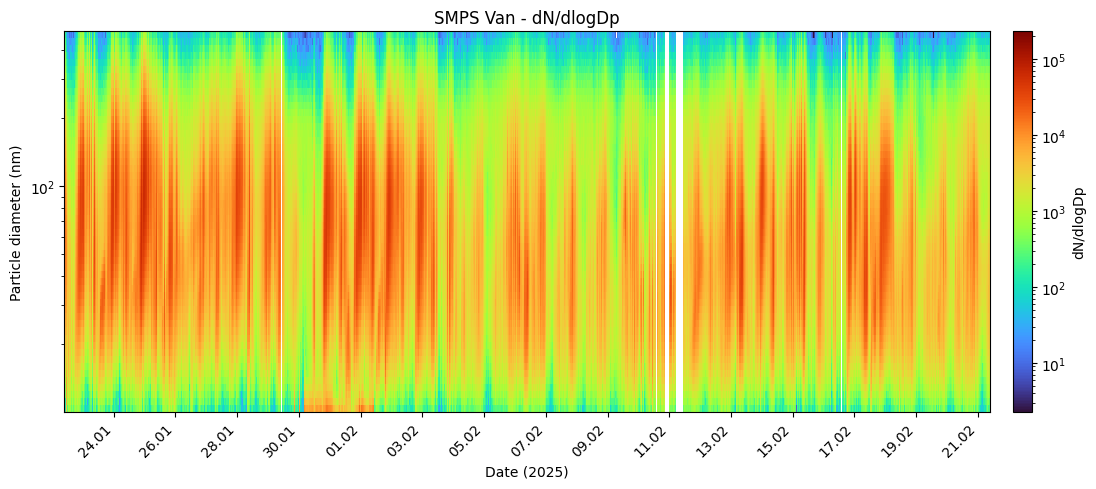

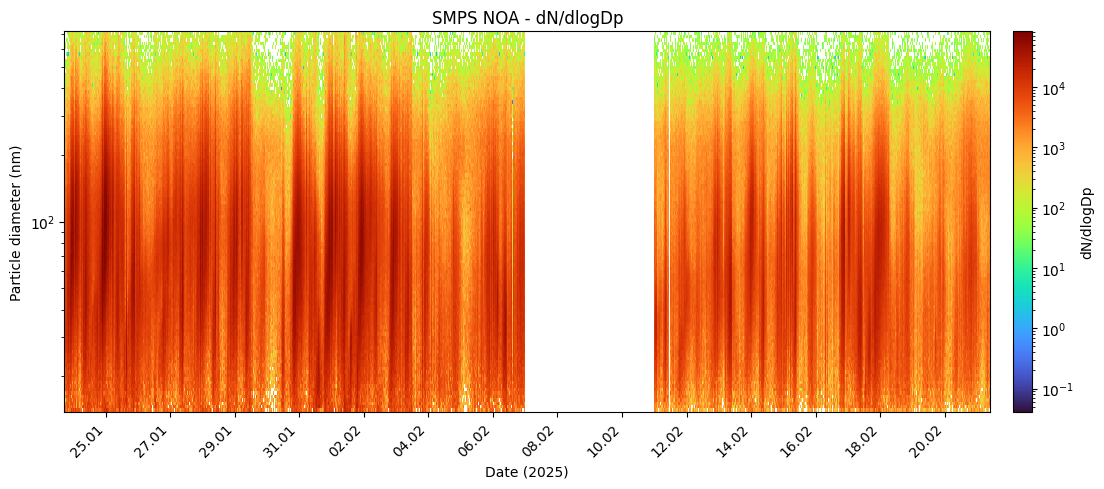

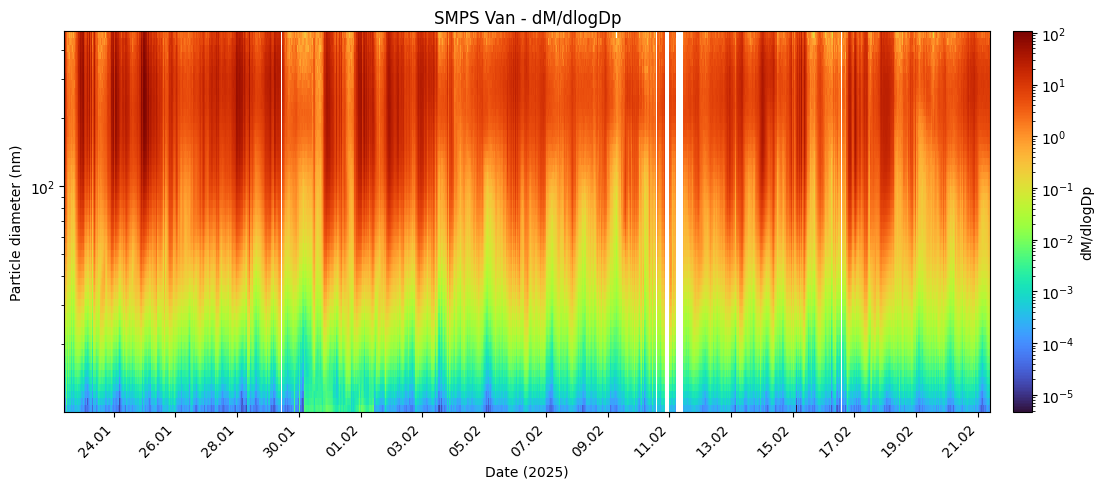

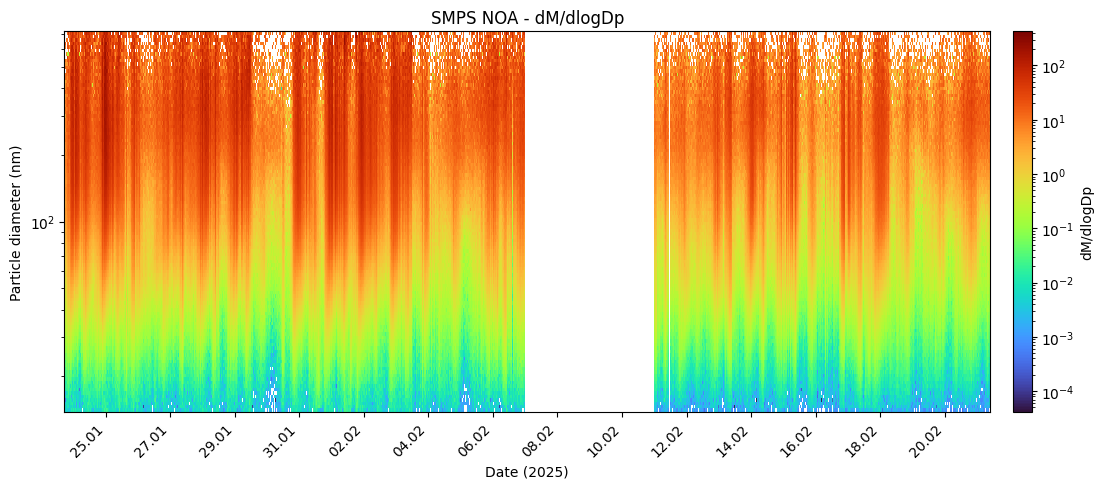

In [58]:
def generate_smps_contour(df, title, z_label="Concentration"):
    df_clean = df.copy()
    df_clean['DateTime'] = pd.to_datetime(df_clean['DateTime'])
    df_clean.set_index('DateTime', inplace=True)

    # 1. FILTER COLUMNS FIRST: Keep only the numeric particle size columns
    size_cols = []
    for col in df_clean.columns:
        try:
            float(col)  # Keep if the column name is a number (diameter)
            size_cols.append(col)
        except ValueError:
            pass        # Ignore if it's text (e.g., 'Lower Size', 'Sample #')

    size_cols = sorted(size_cols, key=float) # Force the columns to sort numerically
    df_sizes = df_clean[size_cols] # Extract strictly the numeric columns

    # 2. RESAMPLE THE TIMELINE: Fix the heatmap gaps
    # Calculate the exact time gap between your scans
    scan_time = df_sizes.index.to_series().diff().median()

    if pd.notnull(scan_time) and scan_time.total_seconds() > 0:
        freq_str = f"{int(scan_time.total_seconds() // 60)}min"
        # Because df_sizes only contains numbers now, .mean() will work perfectly!
        df_sizes = df_sizes.resample(freq_str).mean()

    # 3. PLOT
    x = df_sizes.index
    y = np.array(size_cols, dtype=float)
    z = df_sizes.values.astype(float).T
    z[z <= 0] = np.nan # LogNorm cannot handle zeros or negative values

    fig, ax = plt.subplots(figsize=(12, 5))
    mesh = ax.pcolormesh(x, y, z, norm=LogNorm(), cmap='turbo', shading='auto')

    ax.set_yscale('log')
    ax.set_ylabel('Particle diameter (nm)')
    ax.set_xlabel('Date (2025)')
    ax.set_title(title)
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
    fig.autofmt_xdate(rotation=45, ha='right')

    cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
    cbar.set_label(z_label)

    plt.tight_layout()
    plt.show()

# Re-run your plots
generate_smps_contour(df_smps_van_dndlogdp, title="SMPS Van - dN/dlogDp", z_label="dN/dlogDp")
generate_smps_contour(df_smps_noa_dndlogdp, title="SMPS NOA - dN/dlogDp", z_label="dN/dlogDp")

generate_smps_contour(df_smps_van_dmdlogdp, title="SMPS Van - dM/dlogDp", z_label="dM/dlogDp")
generate_smps_contour(df_smps_noa_dmdlogdp, title="SMPS NOA - dM/dlogDp", z_label="dM/dlogDp")

In [90]:
# ==============================================================================
# 1. HELPER FUNCTION FOR MASS METRICS (dM requires simple summation)
# ==============================================================================
def calculate_smps_pm_hourly(df, time_col='DateTime'):
    df_calc = df.copy()
    df_calc[time_col] = pd.to_datetime(df_calc[time_col])

    # Extract numeric particle diameter columns
    size_cols = []
    for col in df_calc.columns:
        try:
            float(col)
            size_cols.append(col)
        except ValueError:
            pass

    pm01_cols = [col for col in size_cols if float(col) < 100]
    pm05_cols = [col for col in size_cols if float(col) <= 500]

    df_calc['PM0.1'] = df_calc[pm01_cols].sum(axis=1)
    df_calc['PM0.5'] = df_calc[pm05_cols].sum(axis=1)
    df_calc['PM1'] = df_calc[size_cols].sum(axis=1)

    df_calc = df_calc[[time_col, 'PM0.1', 'PM0.5', 'PM1']]
    df_calc.set_index(time_col, inplace=True)
    return df_calc.resample('h').mean().reset_index()


# ==============================================================================
# 2. NUMBER CONCENTRATION INTEGRATION FROM dN/dlogDp
# ==============================================================================
def calculate_smps_number_hourly(df, time_col='DateTime'):
    df_calc = df.copy()
    df_calc[time_col] = pd.to_datetime(df_calc[time_col])

    # Extract and sort particle diameter columns numerically
    size_cols = []
    for col in df_calc.columns:
        try:
            float(col)
            size_cols.append(col)
        except ValueError:
            pass
    size_cols = sorted(size_cols, key=float)

    # Convert nominal diameters to log10 space
    sizes = np.array([float(col) for col in size_cols])
    log_sizes = np.log10(sizes)

    # Dynamically compute dlogDp (bin resolution in log space) for each channel
    dlogDp = np.zeros_like(log_sizes)
    if len(log_sizes) > 1:
        # Central difference formula for intermediate channels
        dlogDp[1:-1] = (log_sizes[2:] - log_sizes[:-2]) / 2
        # Endpoints handle boundary gaps
        dlogDp[0] = log_sizes[1] - log_sizes[0]
        dlogDp[-1] = log_sizes[-1] - log_sizes[-2]
    else:
        dlogDp[0] = 1.0

    # Determine which indices correspond to >10nm and >50nm
    n10_indices = [i for i, s in enumerate(sizes) if s > 10]
    n50_indices = [i for i, s in enumerate(sizes) if s > 50]

    # Initialize arrays to accumulate actual particle counts (dN)
    n10_totals = np.zeros(len(df_calc))
    n50_totals = np.zeros(len(df_calc))

    # Perform integration: dN = (dN/dlogDp) * dlogDp
    for idx in n10_indices:
        col_name = size_cols[idx]
        n10_totals += df_calc[col_name].fillna(0).values * dlogDp[idx]

    for idx in n50_indices:
        col_name = size_cols[idx]
        n50_totals += df_calc[col_name].fillna(0).values * dlogDp[idx]

    df_calc['N10'] = n10_totals
    df_calc['N50'] = n50_totals

    df_calc = df_calc[[time_col, 'N10', 'N50']]
    df_calc.set_index(time_col, inplace=True)
    return df_calc.resample('h').mean().reset_index()


# ==============================================================================
# 3. PROCESSING DATASETS AND MERGING METRICS
# ==============================================================================

# --- Van SMPS ---
df_smps_van_pm_hourly = calculate_smps_pm_hourly(df_smps_van_dm, time_col='DateTime')
df_smps_van_n_hourly = calculate_smps_number_hourly(df_smps_van_dndlogdp, time_col='DateTime')
df_smps_van_pm_hourly = pd.merge(df_smps_van_pm_hourly, df_smps_van_n_hourly, on='DateTime', how='left')

# --- NOA SMPS ---
df_smps_noa_pm_hourly = calculate_smps_pm_hourly(df_smps_noa_dm, time_col='DateTime')
df_smps_noa_n_hourly = calculate_smps_number_hourly(df_smps_noa_dndlogdp, time_col='DateTime')
df_smps_noa_pm_hourly = pd.merge(df_smps_noa_pm_hourly, df_smps_noa_n_hourly, on='DateTime', how='left')

# --- CPC50 ---
df_cpc50['DateTime'] = pd.to_datetime(df_cpc50['DateTime_CPC50'])
df_cpc50_hourly = df_cpc50.resample('h', on='DateTime')['PM0.1_CPC50', 'N50_CPC50'].mean().reset_index()


# ==============================================================================
# 4. DISPLAY RESULTS
# ==============================================================================
print("Van SMPS Hourly Averages (PM0.1, PM0.5, PM1, N10, and N50):")
display(df_smps_van_pm_hourly)

print("\nNOA SMPS Hourly Averages (PM0.1, PM0.5, PM1, N14, and N50):")
display(df_smps_noa_pm_hourly)

display(df_cpc50_hourly)

Van SMPS Hourly Averages (PM0.1, PM0.5, PM1, N10, and N50):


,DateTime,PM0.1,PM0.5,PM1,N10,N50
0,2025-01-22 09:00:00,1.695531,17.852274,17.852274,19266.285335,12316.716767
1,2025-01-22 10:00:00,0.793972,7.517588,7.517588,8913.831505,5639.962830
2,2025-01-22 11:00:00,0.492909,3.356513,3.356513,6902.577848,3206.927352
3,2025-01-22 12:00:00,0.213267,1.551906,1.551906,3425.265796,1409.423556
4,2025-01-22 13:00:00,0.162352,1.271633,1.271633,2643.262593,1082.168856
...,...,...,...,...,...,...
716,2025-02-21 05:00:00,0.104363,3.721783,3.721783,2129.586986,1177.540988
717,2025-02-21 06:00:00,0.117755,3.868102,3.868102,2560.945879,1257.069150
718,2025-02-21 07:00:00,0.149679,3.882372,3.882372,3320.577311,1416.730747
719,2025-02-21 08:00:00,0.166846,3.778908,3.778908,3415.878353,1482.378495



NOA SMPS Hourly Averages (PM0.1, PM0.5, PM1, N14, and N50):


,DateTime,PM0.1,PM0.5,PM1,N10,N50
0,2025-01-23 17:00:00,0.619097,5.389105,7.619661,9150.918302,3766.155047
1,2025-01-23 18:00:00,0.566483,5.330272,6.278142,8082.519272,3637.520968
2,2025-01-23 19:00:00,1.131198,10.720396,13.037429,15078.792637,7392.293262
3,2025-01-23 20:00:00,1.242629,10.918091,13.073332,16114.795876,8063.576304
4,2025-01-23 21:00:00,1.859684,16.528267,19.578582,21193.029030,12218.261091
...,...,...,...,...,...,...
684,2025-02-21 05:00:00,0.099599,6.704054,7.565265,2069.943221,1228.123662
685,2025-02-21 06:00:00,0.108587,6.783361,7.576980,2386.701222,1300.798625
686,2025-02-21 07:00:00,0.127476,6.758624,7.613412,2931.526944,1401.081982
687,2025-02-21 08:00:00,0.147470,6.556591,7.408400,3125.711026,1490.482030


,DateTime,PM0.1_CPC50,N50_CPC50
0,2025-01-29 18:00:00,0.191857,1199.106512
1,2025-01-29 19:00:00,0.183232,1145.200500
2,2025-01-29 20:00:00,0.181457,1134.105667
3,2025-01-29 21:00:00,0.182497,1140.607500
4,2025-01-29 22:00:00,0.165724,1035.776667
...,...,...,...
539,2025-02-21 05:00:00,0.248657,1554.105333
540,2025-02-21 06:00:00,0.246571,1541.068167
541,2025-02-21 07:00:00,0.249255,1557.841000
542,2025-02-21 08:00:00,0.265479,1659.241167


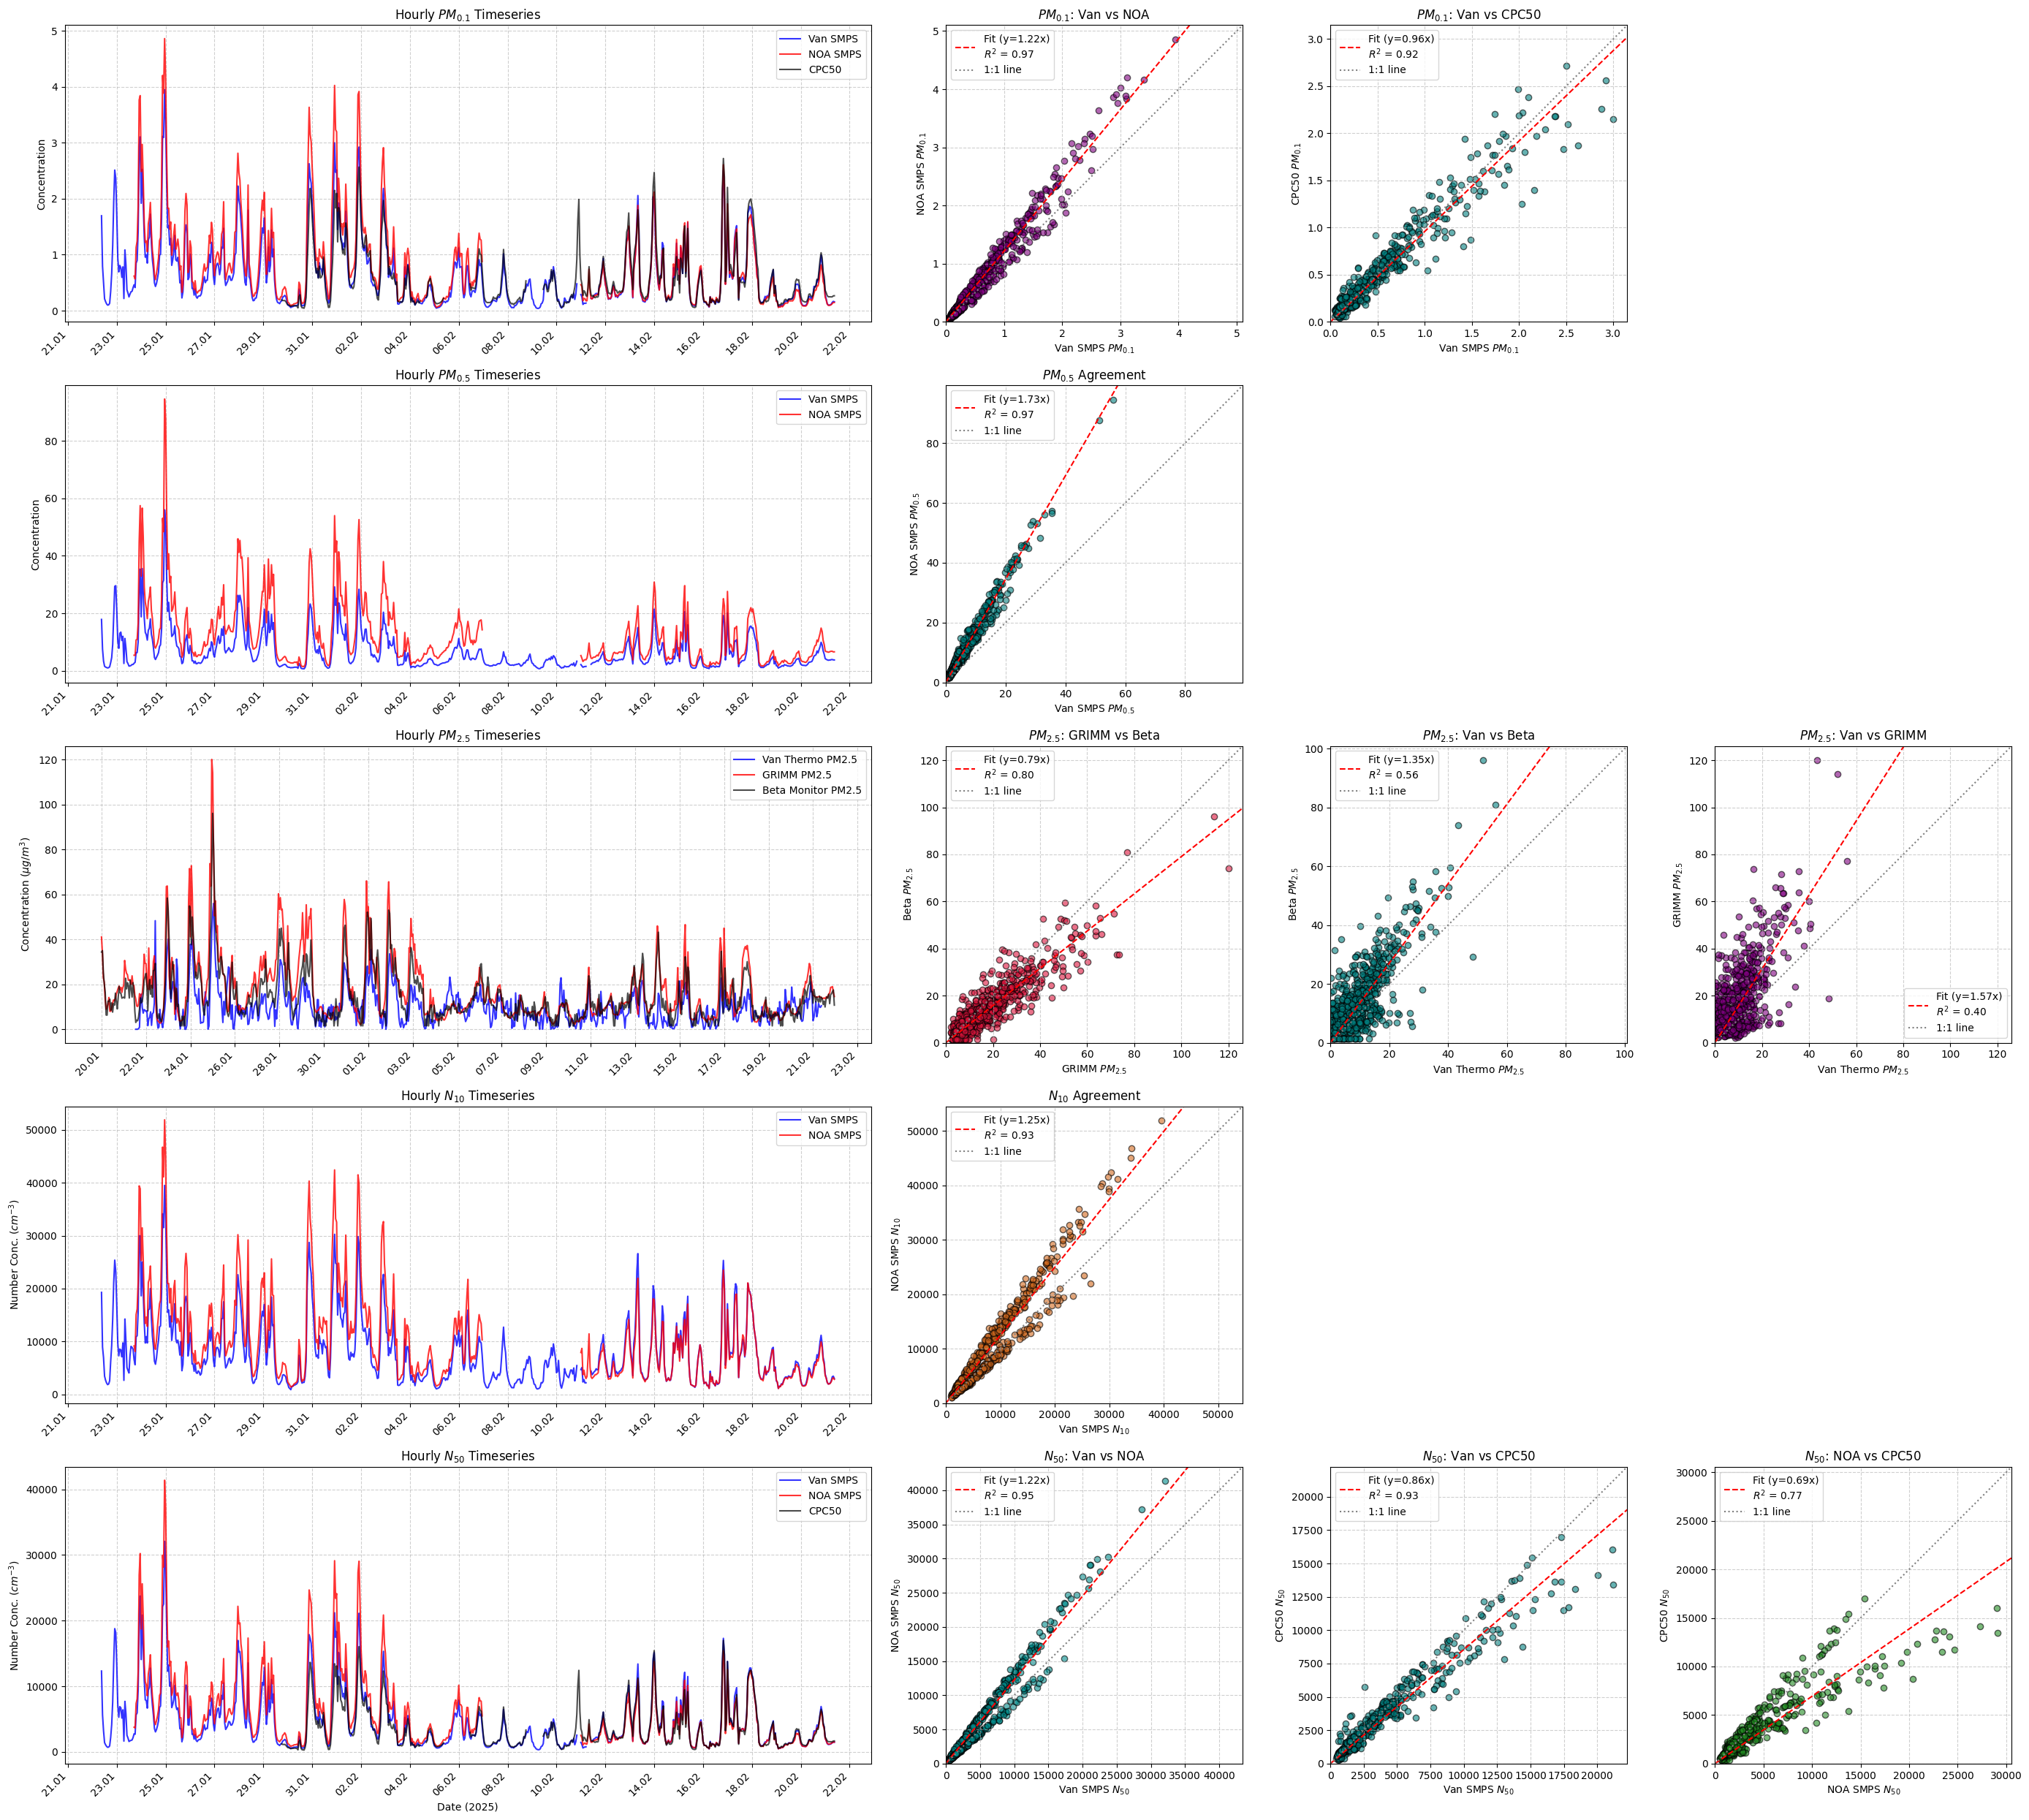

In [92]:
# ==============================================================================
# 1. DATA PREPARATION: SMPS metrics (PM0.1, PM0.5, N10, N50)
# ==============================================================================
# Use how='outer' (outer join) to preserve all timestamps from both SMPS datasets
df_merged = pd.merge(
    df_smps_van_pm_hourly,
    df_smps_noa_pm_hourly,
    on='DateTime',
    suffixes=('_Van', '_NOA'),
    how='outer'
)

# Include all timestamps from CPC50 dataset (brings in PM0.1_CPC50 and N50_CPC50)
df_merged = pd.merge(df_merged, df_cpc50_hourly, on='DateTime', how='outer')

# Sort by DateTime so the timeseries lines connect chronologically
df_merged = df_merged.sort_values('DateTime').reset_index(drop=True)

# ==============================================================================
# 2. DATA PREPARATION: PM2.5
# ==============================================================================
# Extract the Van PM2.5 data and rename the column for clarity
df_van_pm25 = df_pm25_clean_hourly[['Datetime', 'pm']].rename(columns={'pm': 'PM2.5_Van'})
df_van_pm25 = df_van_pm25[df_van_pm25['Datetime'] >= '2025-01-20']

# Dynamically match column names containing 'GRIMM' or 'Beta' from NOA dataset
try:
    grimm_col = [col for col in df_noa_all.columns if 'GRIMM' in col][0]
    beta_col = [col for col in df_noa_all.columns if 'Beta' in col][0]

    df_noa_pm25 = df_noa_all[['Datetime', grimm_col, beta_col]].rename(columns={
        grimm_col: 'PM2.5_GRIMM',
        beta_col: 'PM2.5_Beta'
    })
except IndexError:
    raise ValueError("Could not automatically locate columns containing 'GRIMM' or 'Beta' in df_noa_all.")

# Merge using an outer join to keep full datasets from all instruments
df_pm25_merged = pd.merge(
    df_van_pm25,
    df_noa_pm25,
    on='Datetime',
    how='outer'
).sort_values('Datetime').reset_index(drop=True)


# ==============================================================================
# HELPER FUNCTION: Calculates slope and R² through zero (y = mx)
# ==============================================================================
def get_slope_and_r2_through_zero(x, y):
    mask = x.notna() & y.notna()
    x_clean = x[mask]
    y_clean = y[mask]

    if len(x_clean) == 0:
        return 1.0, 0.0

    x_matrix = x_clean.values[:, np.newaxis]
    slope, _, _, _ = np.linalg.lstsq(x_matrix, y_clean.values, rcond=None)
    slope_val = slope[0]

    y_pred = slope_val * x_clean.values
    ss_res = np.sum((y_clean.values - y_pred) ** 2)
    ss_tot = np.sum((y_clean.values - np.mean(y_clean.values)) ** 2)

    r2_val = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0
    return slope_val, r2_val


# ==============================================================================
# 3. SETUP FIGURE LAYOUT (5 Rows x 4 Columns)
# ==============================================================================
fig, axes = plt.subplots(
    5, 4,
    figsize=(28, 25),
    gridspec_kw={'width_ratios': [2.5, 1, 1, 1]}
)

# Hide the unused empty subplots across rows to keep layout clean
fig.delaxes(axes[0, 3])  # Row 1, Column 4 (PM0.1)
fig.delaxes(axes[1, 2])  # Row 2, Column 3 (PM0.5)
fig.delaxes(axes[1, 3])  # Row 2, Column 4 (PM0.5)
fig.delaxes(axes[3, 2])  # Row 4, Column 3 (N10)
fig.delaxes(axes[3, 3])  # Row 4, Column 4 (N10)
# NOTE: Row 5 (N50) is now completely active and populated across all columns.


# ==============================================================================
# ROW 1: PM0.1 Analysis
# ==============================================================================
ax_ts_01 = axes[0, 0]
ax_sc_01 = axes[0, 1]
ax_sc_cpc = axes[0, 2]

# Timeseries PM0.1
ax_ts_01.plot(df_merged['DateTime'], df_merged['PM0.1_Van'], label='Van SMPS', color='blue', alpha=0.8)
ax_ts_01.plot(df_merged['DateTime'], df_merged['PM0.1_NOA'], label='NOA SMPS', color='red', alpha=0.8)
ax_ts_01.plot(df_merged['DateTime'], df_merged['PM0.1_CPC50'], label='CPC50', color='black', alpha=0.7)
ax_ts_01.set_ylabel('Concentration')
ax_ts_01.set_title('Hourly $PM_{0.1}$ Timeseries')
ax_ts_01.legend()
ax_ts_01.grid(True, linestyle='--', alpha=0.6)

# Scatter 1: Van SMPS vs NOA SMPS PM0.1
df_sc01_clean = df_merged[['PM0.1_Van', 'PM0.1_NOA']].dropna()
slope_01, r2_01 = get_slope_and_r2_through_zero(df_sc01_clean['PM0.1_Van'], df_sc01_clean['PM0.1_NOA'])
max_val_01 = max(df_sc01_clean['PM0.1_Van'].max(), df_sc01_clean['PM0.1_NOA'].max()) * 1.05

ax_sc_01.scatter(df_sc01_clean['PM0.1_Van'], df_sc01_clean['PM0.1_NOA'], alpha=0.6, color='purple', edgecolor='k')
x_vals_01 = np.array([0, max_val_01])
ax_sc_01.plot(x_vals_01, slope_01 * x_vals_01, color='red', linestyle='--', label=f'Fit (y={slope_01:.2f}x)\n$R^2$ = {r2_01:.2f}')
ax_sc_01.plot(x_vals_01, x_vals_01, color='grey', linestyle=':', label='1:1 line')
ax_sc_01.set_xlim(0, max_val_01)
ax_sc_01.set_ylim(0, max_val_01)
ax_sc_01.set_xlabel('Van SMPS $PM_{0.1}$')
ax_sc_01.set_ylabel('NOA SMPS $PM_{0.1}$')
ax_sc_01.set_title('$PM_{0.1}$: Van vs NOA')
ax_sc_01.legend()
ax_sc_01.grid(True, linestyle='--', alpha=0.6)
ax_sc_01.set_box_aspect(1)

# Scatter 2: Van SMPS vs CPC50 PM0.1
df_sccpc_clean = df_merged[['PM0.1_Van', 'PM0.1_CPC50']].dropna()
slope_cpc, r2_cpc = get_slope_and_r2_through_zero(df_sccpc_clean['PM0.1_Van'], df_sccpc_clean['PM0.1_CPC50'])
max_val_cpc = max(df_sccpc_clean['PM0.1_Van'].max(), df_sccpc_clean['PM0.1_CPC50'].max()) * 1.05

ax_sc_cpc.scatter(df_sccpc_clean['PM0.1_Van'], df_sccpc_clean['PM0.1_CPC50'], alpha=0.6, color='teal', edgecolor='k')
x_vals_cpc = np.array([0, max_val_cpc])
ax_sc_cpc.plot(x_vals_cpc, slope_cpc * x_vals_cpc, color='red', linestyle='--', label=f'Fit (y={slope_cpc:.2f}x)\n$R^2$ = {r2_cpc:.2f}')
ax_sc_cpc.plot(x_vals_cpc, x_vals_cpc, color='grey', linestyle=':', label='1:1 line')
ax_sc_cpc.set_xlim(0, max_val_cpc)
ax_sc_cpc.set_ylim(0, max_val_cpc)
ax_sc_cpc.set_xlabel('Van SMPS $PM_{0.1}$')
ax_sc_cpc.set_ylabel('CPC50 $PM_{0.1}$')
ax_sc_cpc.set_title('$PM_{0.1}$: Van vs CPC50')
ax_sc_cpc.legend()
ax_sc_cpc.grid(True, linestyle='--', alpha=0.6)
ax_sc_cpc.set_box_aspect(1)


# ==============================================================================
# ROW 2: PM0.5 Analysis
# ==============================================================================
ax_ts_05 = axes[1, 0]
ax_sc_05 = axes[1, 1]

# Timeseries PM0.5
ax_ts_05.plot(df_merged['DateTime'], df_merged['PM0.5_Van'], label='Van SMPS', color='blue', alpha=0.8)
ax_ts_05.plot(df_merged['DateTime'], df_merged['PM0.5_NOA'], label='NOA SMPS', color='red', alpha=0.8)
ax_ts_05.set_ylabel('Concentration')
ax_ts_05.set_title('Hourly $PM_{0.5}$ Timeseries')
ax_ts_05.legend()
ax_ts_05.grid(True, linestyle='--', alpha=0.6)

# Scatter PM0.5
df_sc05_clean = df_merged[['PM0.5_Van', 'PM0.5_NOA']].dropna()
slope_05, r2_05 = get_slope_and_r2_through_zero(df_sc05_clean['PM0.5_Van'], df_sc05_clean['PM0.5_NOA'])
max_val_05 = max(df_sc05_clean['PM0.5_Van'].max(), df_sc05_clean['PM0.5_NOA'].max()) * 1.05

ax_sc_05.scatter(df_sc05_clean['PM0.5_Van'], df_sc05_clean['PM0.5_NOA'], alpha=0.6, color='teal', edgecolor='k')
x_vals_05 = np.array([0, max_val_05])
ax_sc_05.plot(x_vals_05, slope_05 * x_vals_05, color='red', linestyle='--', label=f'Fit (y={slope_05:.2f}x)\n$R^2$ = {r2_05:.2f}')
ax_sc_05.plot(x_vals_05, x_vals_05, color='grey', linestyle=':', label='1:1 line')
ax_sc_05.set_xlim(0, max_val_05)
ax_sc_05.set_ylim(0, max_val_05)
ax_sc_05.set_xlabel('Van SMPS $PM_{0.5}$')
ax_sc_05.set_ylabel('NOA SMPS $PM_{0.5}$')
ax_sc_05.set_title('$PM_{0.5}$ Agreement')
ax_sc_05.legend()
ax_sc_05.grid(True, linestyle='--', alpha=0.6)
ax_sc_05.set_box_aspect(1)


# ==============================================================================
# ROW 3: PM2.5 Analysis
# ==============================================================================
ax_ts_25 = axes[2, 0]
ax_sc1_25 = axes[2, 3]
ax_sc2_25 = axes[2, 2]
ax_sc3_25 = axes[2, 1]

# Timeseries PM2.5
ax_ts_25.plot(df_pm25_merged['Datetime'], df_pm25_merged['PM2.5_Van'], label='Van Thermo PM2.5', color='blue', alpha=0.8)
ax_ts_25.plot(df_pm25_merged['Datetime'], df_pm25_merged['PM2.5_GRIMM'], label='GRIMM PM2.5', color='red', alpha=0.8)
ax_ts_25.plot(df_pm25_merged['Datetime'], df_pm25_merged['PM2.5_Beta'], label='Beta Monitor PM2.5', color='black', alpha=0.7)
ax_ts_25.set_ylabel(r'Concentration ($\mu g/m^3$)')
ax_ts_25.set_title('Hourly $PM_{2.5}$ Timeseries')
ax_ts_25.legend()
ax_ts_25.grid(True, linestyle='--', alpha=0.6)

# Scatter Plot 1: GRIMM vs Beta
df_sc3_clean = df_pm25_merged[['PM2.5_GRIMM', 'PM2.5_Beta']].dropna()
slope3, r2_3 = get_slope_and_r2_through_zero(df_sc3_clean['PM2.5_GRIMM'], df_sc3_clean['PM2.5_Beta'])
max_val3 = max(df_sc3_clean['PM2.5_GRIMM'].max(), df_sc3_clean['PM2.5_Beta'].max()) * 1.05

ax_sc3_25.scatter(df_sc3_clean['PM2.5_GRIMM'], df_sc3_clean['PM2.5_Beta'], alpha=0.6, color='crimson', edgecolor='k')
x_vals3 = np.array([0, max_val3])
ax_sc3_25.plot(x_vals3, slope3 * x_vals3, color='red', linestyle='--', label=f'Fit (y={slope3:.2f}x)\n$R^2$ = {r2_3:.2f}')
ax_sc3_25.plot(x_vals3, x_vals3, color='grey', linestyle=':', label='1:1 line')
ax_sc3_25.set_xlim(0, max_val3)
ax_sc3_25.set_ylim(0, max_val3)
ax_sc3_25.set_xlabel('GRIMM $PM_{2.5}$')
ax_sc3_25.set_ylabel('Beta $PM_{2.5}$')
ax_sc3_25.set_title('$PM_{2.5}$: GRIMM vs Beta')
ax_sc3_25.legend()
ax_sc3_25.grid(True, linestyle='--', alpha=0.6)
ax_sc3_25.set_box_aspect(1)

# Scatter Plot 2: Van vs Beta
df_sc2_clean = df_pm25_merged[['PM2.5_Van', 'PM2.5_Beta']].dropna()
slope2, r2_2 = get_slope_and_r2_through_zero(df_sc2_clean['PM2.5_Van'], df_sc2_clean['PM2.5_Beta'])
max_val2 = max(df_sc2_clean['PM2.5_Van'].max(), df_sc2_clean['PM2.5_Beta'].max()) * 1.05

ax_sc2_25.scatter(df_sc2_clean['PM2.5_Van'], df_sc2_clean['PM2.5_Beta'], alpha=0.6, color='teal', edgecolor='k')
x_vals2 = np.array([0, max_val2])
ax_sc2_25.plot(x_vals2, slope2 * x_vals2, color='red', linestyle='--', label=f'Fit (y={slope2:.2f}x)\n$R^2$ = {r2_2:.2f}')
ax_sc2_25.plot(x_vals2, x_vals2, color='grey', linestyle=':', label='1:1 line')
ax_sc2_25.set_xlim(0, max_val2)
ax_sc2_25.set_ylim(0, max_val2)
ax_sc2_25.set_xlabel('Van Thermo $PM_{2.5}$')
ax_sc2_25.set_ylabel('Beta $PM_{2.5}$')
ax_sc2_25.set_title('$PM_{2.5}$: Van vs Beta')
ax_sc2_25.legend()
ax_sc2_25.grid(True, linestyle='--', alpha=0.6)
ax_sc2_25.set_box_aspect(1)

# Scatter Plot 3: Van vs GRIMM
df_sc1_clean = df_pm25_merged[['PM2.5_Van', 'PM2.5_GRIMM']].dropna()
slope1, r2_1 = get_slope_and_r2_through_zero(df_sc1_clean['PM2.5_Van'], df_sc1_clean['PM2.5_GRIMM'])
max_val1 = max(df_sc1_clean['PM2.5_Van'].max(), df_sc1_clean['PM2.5_GRIMM'].max()) * 1.05

ax_sc1_25.scatter(df_sc1_clean['PM2.5_Van'], df_sc1_clean['PM2.5_GRIMM'], alpha=0.6, color='purple', edgecolor='k')
x_vals1 = np.array([0, max_val1])
ax_sc1_25.plot(x_vals1, slope1 * x_vals1, color='red', linestyle='--', label=f'Fit (y={slope1:.2f}x)\n$R^2$ = {r2_1:.2f}')
ax_sc1_25.plot(x_vals1, x_vals1, color='grey', linestyle=':', label='1:1 line')
ax_sc1_25.set_xlim(0, max_val1)
ax_sc1_25.set_ylim(0, max_val1)
ax_sc1_25.set_xlabel('Van Thermo $PM_{2.5}$')
ax_sc1_25.set_ylabel('GRIMM $PM_{2.5}$')
ax_sc1_25.set_title('$PM_{2.5}$: Van vs GRIMM')
ax_sc1_25.legend()
ax_sc1_25.grid(True, linestyle='--', alpha=0.6)
ax_sc1_25.set_box_aspect(1)


# ==============================================================================
# ROW 4: N10 Analysis
# ==============================================================================
ax_ts_10 = axes[3, 0]
ax_sc_10 = axes[3, 1]

# Timeseries N10
ax_ts_10.plot(df_merged['DateTime'], df_merged['N10_Van'], label='Van SMPS', color='blue', alpha=0.8)
ax_ts_10.plot(df_merged['DateTime'], df_merged['N10_NOA'], label='NOA SMPS', color='red', alpha=0.8)
ax_ts_10.set_ylabel(r'Number Conc. ($cm^{-3}$)')
ax_ts_10.set_title('Hourly $N_{10}$ Timeseries')
ax_ts_10.legend()
ax_ts_10.grid(True, linestyle='--', alpha=0.6)

# Scatter N10
df_sc10_clean = df_merged[['N10_Van', 'N10_NOA']].dropna()
slope_10, r2_10 = get_slope_and_r2_through_zero(df_sc10_clean['N10_Van'], df_sc10_clean['N10_NOA'])
max_val_10 = max(df_sc10_clean['N10_Van'].max(), df_sc10_clean['N10_NOA'].max()) * 1.05

ax_sc_10.scatter(df_sc10_clean['N10_Van'], df_sc10_clean['N10_NOA'], alpha=0.6, color='chocolate', edgecolor='k')
x_vals_10 = np.array([0, max_val_10])
ax_sc_10.plot(x_vals_10, slope_10 * x_vals_10, color='red', linestyle='--', label=f'Fit (y={slope_10:.2f}x)\n$R^2$ = {r2_10:.2f}')
ax_sc_10.plot(x_vals_10, x_vals_10, color='grey', linestyle=':', label='1:1 line')
ax_sc_10.set_xlim(0, max_val_10)
ax_sc_10.set_ylim(0, max_val_10)
ax_sc_10.set_xlabel('Van SMPS $N_{10}$')
ax_sc_10.set_ylabel('NOA SMPS $N_{10}$')
ax_sc_10.set_title('$N_{10}$ Agreement')
ax_sc_10.legend()
ax_sc_10.grid(True, linestyle='--', alpha=0.6)
ax_sc_10.set_box_aspect(1)


# ==============================================================================
# ROW 5: N50 Analysis
# ==============================================================================
ax_ts_50 = axes[4, 0]
ax_sc1_50 = axes[4, 1]  # Van vs NOA
ax_sc2_50 = axes[4, 2]  # Van vs CPC50
ax_sc3_50 = axes[4, 3]  # NOA vs CPC50

# Timeseries N50 (Now includes CPC50 timeline)
ax_ts_50.plot(df_merged['DateTime'], df_merged['N50_Van'], label='Van SMPS', color='blue', alpha=0.8)
ax_ts_50.plot(df_merged['DateTime'], df_merged['N50_NOA'], label='NOA SMPS', color='red', alpha=0.8)
ax_ts_50.plot(df_merged['DateTime'], df_merged['N50_CPC50'], label='CPC50', color='black', alpha=0.7)
ax_ts_50.set_ylabel(r'Number Conc. ($cm^{-3}$)')
ax_ts_50.set_title('Hourly $N_{50}$ Timeseries')
ax_ts_50.legend()
ax_ts_50.grid(True, linestyle='--', alpha=0.6)

# Scatter Panel 1: Van SMPS vs NOA SMPS N50
df_sc50_vn = df_merged[['N50_Van', 'N50_NOA']].dropna()
slope_50_vn, r2_50_vn = get_slope_and_r2_through_zero(df_sc50_vn['N50_Van'], df_sc50_vn['N50_NOA'])
max_val_50_vn = max(df_sc50_vn['N50_Van'].max(), df_sc50_vn['N50_NOA'].max()) * 1.05

ax_sc1_50.scatter(df_sc50_vn['N50_Van'], df_sc50_vn['N50_NOA'], alpha=0.6, color='darkcyan', edgecolor='k')
x_vals_50_vn = np.array([0, max_val_50_vn])
ax_sc1_50.plot(x_vals_50_vn, slope_50_vn * x_vals_50_vn, color='red', linestyle='--', label=f'Fit (y={slope_50_vn:.2f}x)\n$R^2$ = {r2_50_vn:.2f}')
ax_sc1_50.plot(x_vals_50_vn, x_vals_50_vn, color='grey', linestyle=':', label='1:1 line')
ax_sc1_50.set_xlim(0, max_val_50_vn)
ax_sc1_50.set_ylim(0, max_val_50_vn)
ax_sc1_50.set_xlabel('Van SMPS $N_{50}$')
ax_sc1_50.set_ylabel('NOA SMPS $N_{50}$')
ax_sc1_50.set_title('$N_{50}$: Van vs NOA')
ax_sc1_50.legend()
ax_sc1_50.grid(True, linestyle='--', alpha=0.6)
ax_sc1_50.set_box_aspect(1)

# Scatter Panel 2: Van SMPS vs CPC50 N50
df_sc50_vc = df_merged[['N50_Van', 'N50_CPC50']].dropna()
slope_50_vc, r2_50_vc = get_slope_and_r2_through_zero(df_sc50_vc['N50_Van'], df_sc50_vc['N50_CPC50'])
max_val_50_vc = max(df_sc50_vc['N50_Van'].max(), df_sc50_vc['N50_CPC50'].max()) * 1.05

ax_sc2_50.scatter(df_sc50_vc['N50_Van'], df_sc50_vc['N50_CPC50'], alpha=0.6, color='teal', edgecolor='k')
x_vals_50_vc = np.array([0, max_val_50_vc])
ax_sc2_50.plot(x_vals_50_vc, slope_50_vc * x_vals_50_vc, color='red', linestyle='--', label=f'Fit (y={slope_50_vc:.2f}x)\n$R^2$ = {r2_50_vc:.2f}')
ax_sc2_50.plot(x_vals_50_vc, x_vals_50_vc, color='grey', linestyle=':', label='1:1 line')
ax_sc2_50.set_xlim(0, max_val_50_vc)
ax_sc2_50.set_ylim(0, max_val_50_vc)
ax_sc2_50.set_xlabel('Van SMPS $N_{50}$')
ax_sc2_50.set_ylabel('CPC50 $N_{50}$')
ax_sc2_50.set_title('$N_{50}$: Van vs CPC50')
ax_sc2_50.legend()
ax_sc2_50.grid(True, linestyle='--', alpha=0.6)
ax_sc2_50.set_box_aspect(1)

# Scatter Panel 3: NOA SMPS vs CPC50 N50
df_sc50_nc = df_merged[['N50_NOA', 'N50_CPC50']].dropna()
slope_50_nc, r2_50_nc = get_slope_and_r2_through_zero(df_sc50_nc['N50_NOA'], df_sc50_nc['N50_CPC50'])
max_val_50_nc = max(df_sc50_nc['N50_NOA'].max(), df_sc50_nc['N50_CPC50'].max()) * 1.05

ax_sc3_50.scatter(df_sc50_nc['N50_NOA'], df_sc50_nc['N50_CPC50'], alpha=0.6, color='forestgreen', edgecolor='k')
x_vals_50_nc = np.array([0, max_val_50_nc])
ax_sc3_50.plot(x_vals_50_nc, slope_50_nc * x_vals_50_nc, color='red', linestyle='--', label=f'Fit (y={slope_50_nc:.2f}x)\n$R^2$ = {r2_50_nc:.2f}')
ax_sc3_50.plot(x_vals_50_nc, x_vals_50_nc, color='grey', linestyle=':', label='1:1 line')
ax_sc3_50.set_xlim(0, max_val_50_nc)
ax_sc3_50.set_ylim(0, max_val_50_nc)
ax_sc3_50.set_xlabel('NOA SMPS $N_{50}$')
ax_sc3_50.set_ylabel('CPC50 $N_{50}$')
ax_sc3_50.set_title('$N_{50}$: NOA vs CPC50')
ax_sc3_50.legend()
ax_sc3_50.grid(True, linestyle='--', alpha=0.6)
ax_sc3_50.set_box_aspect(1)


# ==============================================================================
# 4. FORMAT TIMESERIES DATE AXES FOR UNIFORM LOOK
# ==============================================================================
# Standardize date labels on all five timeseries panels across rows
for ax in [ax_ts_01, ax_ts_05, ax_ts_25, ax_ts_10, ax_ts_50]:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

# Explicitly label the timeline axis at the very bottom row
ax_ts_50.set_xlabel('Date (2025)')

plt.tight_layout()
plt.show()

## Number and Mass size distributions from SMPSs

In [67]:
# ── extract numeric size-bin column names ─────────────────────────────
def get_size_cols(df):
    """Return sorted list of column names that are numeric particle diameters."""
    cols = []
    for c in df.columns:
        try:
            float(c)
            cols.append(c)
        except (ValueError, TypeError):
            pass
    return sorted(cols, key=float)

# ── compute daily-mean distribution for one calendar date ─────────────

def daily_avg(df, date, size_cols):
    """
    Parameters
    ----------
    df         : DataFrame with a parsed 'DateTime' column
    date       : datetime.date
    size_cols  : list of numeric column names (particle diameters)

    Returns
    -------
    dp     : np.ndarray  particle diameters (nm)
    values : np.ndarray  mean concentration for the requested date
             (all-NaN if no data exist for that date)
    """
    mask   = df["DateTime"].dt.date == date
    dp     = np.array([float(c) for c in size_cols])
    values = df.loc[mask, size_cols].mean(skipna=True).values.astype(float)
    return dp, values

# ── draw one size-distribution panel ──────────────────────────────────

def draw_panel(ax, dp_van, v_van, dp_noa, v_noa, ylabel):
    """
    Plot Van and NOA distributions on a single Axes.
    Handles gracefully when one or both instruments have no data.
    """
    has_van = np.any(np.isfinite(v_van) & (v_van > 0))
    has_noa = np.any(np.isfinite(v_noa) & (v_noa > 0))

    if has_van:
        ax.plot(dp_van, v_van,
                color="#1f77b4", marker="o", ms=3, lw=2.0, alpha=0.85,
                label="Van SMPS")
    if has_noa:
        ax.plot(dp_noa, v_noa,
                color="#ff7f0e", marker="s", ms=3, lw=2.0, alpha=0.85,
                label="NOA SMPS")
    if not has_van and not has_noa:
        ax.text(0.5, 0.5, "No data available",
                transform=ax.transAxes, ha="center", va="center",
                fontsize=12, color="#aaaaaa", fontstyle="italic")

    ax.set_xscale("log")
    ax.set_xlim(9, 800)                        # covers both instruments (10–710 nm)
    ax.set_xlabel("$D_p$ (nm)", fontsize=10, labelpad=4)
    ax.set_ylabel(ylabel, fontsize=10, labelpad=4)
    ax.xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: str(int(round(x)))))
    ax.grid(True, which="both", ls=":", alpha=0.5, color="#999999")
    ax.tick_params(labelsize=9)

    # y-axis: 0 to 120 % of the day's maximum — adapts to each day's range
    all_vals = np.concatenate([
        v_van[np.isfinite(v_van) & (v_van >= 0)] if has_van else np.array([]),
        v_noa[np.isfinite(v_noa) & (v_noa >= 0)] if has_noa else np.array([]),
    ])
    if len(all_vals) > 0:
        ax.set_ylim(bottom=0, top=all_vals.max() * 1.20)

    if has_van or has_noa:
        ax.legend(fontsize=9, loc="upper right",
                  frameon=True, framealpha=0.85, edgecolor="#cccccc")


# ── Prepare the four SMPS DataFrames ──────────────────────────────────────────

for _df in [df_smps_van_dndlogdp, df_smps_van_dmdlogdp,
            df_smps_noa_dndlogdp, df_smps_noa_dmdlogdp]:
    _df["DateTime"] = pd.to_datetime(_df["DateTime"])

VAN_DN = get_size_cols(df_smps_van_dndlogdp)   # 54 bins, 10.4–469.8 nm
VAN_DM = get_size_cols(df_smps_van_dmdlogdp)
NOA_DN = get_size_cols(df_smps_noa_dndlogdp)   # 110 bins, 14.1–710.5 nm
NOA_DM = get_size_cols(df_smps_noa_dmdlogdp)

# Union of dates present in either instrument after cleaning.
# NOA rows for the troubleshooting period (Feb 7–10) have already been
# removed by the cleaning cell above, so those days will automatically
# appear as Van-only slides.
all_dates = sorted(
    set(df_smps_van_dndlogdp["DateTime"].dt.date.unique()) |
    set(df_smps_noa_dndlogdp["DateTime"].dt.date.unique())
)
noa_dates = set(df_smps_noa_dndlogdp["DateTime"].dt.date.unique())

print(f"Campaign : {all_dates[0]}  →  {all_dates[-1]}")
print(f"Slides   : {len(all_dates)}")
van_only = [d for d in all_dates if d not in noa_dates]
if van_only:
    print(f"Van-only : {', '.join(str(d) for d in van_only)} (no NOA data)")


# ── Build the PowerPoint ───────────────────────────────────────────────────────

prs             = Presentation()
prs.slide_width  = Inches(13.33)   # widescreen 16:9
prs.slide_height = Inches(7.5)
blank_layout    = prs.slide_layouts[6]   # completely blank

for i, date in enumerate(all_dates, 1):

    # --- daily-mean distributions ---
    dp_v_dn, v_v_dn = daily_avg(df_smps_van_dndlogdp, date, VAN_DN)
    dp_n_dn, v_n_dn = daily_avg(df_smps_noa_dndlogdp, date, NOA_DN)
    dp_v_dm, v_v_dm = daily_avg(df_smps_van_dmdlogdp, date, VAN_DM)
    dp_n_dm, v_n_dm = daily_avg(df_smps_noa_dmdlogdp, date, NOA_DM)

    # --- matplotlib figure: two side-by-side panels ---
    fig, (ax_dn, ax_dm) = plt.subplots(
        1, 2, figsize=(12, 5.5),
        facecolor="white", constrained_layout=True
    )

    draw_panel(ax_dn,
               dp_v_dn, v_v_dn, dp_n_dn, v_n_dn,
               ylabel="dN/dlog$D_p$  (#/cm³)")
    ax_dn.set_title("Number Size Distribution",
                    fontsize=11, fontweight="bold", pad=8)

    draw_panel(ax_dm,
               dp_v_dm, v_v_dm, dp_n_dm, v_n_dm,
               ylabel="dM/dlog$D_p$  (µg/m³)")
    ax_dm.set_title("Mass Size Distribution",
                    fontsize=11, fontweight="bold", pad=8)

    # render to an in-memory PNG buffer (not saved to disk)
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=150, bbox_inches="tight",
                facecolor="white")
    buf.seek(0)
    plt.close(fig)

    # --- PPTX slide ---
    slide = prs.slides.add_slide(blank_layout)

    # title (date + day name)
    van_only_flag = date not in noa_dates
    title_text    = f"Daily Size Distribution  —  {date.strftime('%A, %d %B %Y')}"
    if van_only_flag:
        title_text += "  [Van SMPS only]"

    txb = slide.shapes.add_textbox(
        Inches(0.3), Inches(0.10), Inches(12.73), Inches(0.60)
    )
    p   = txb.text_frame.paragraphs[0]
    p.alignment = PP_ALIGN.CENTER
    run = p.add_run()
    run.text           = title_text
    run.font.bold      = True
    run.font.size      = Pt(22)
    run.font.name      = "Calibri"
    run.font.color.rgb = RGBColor(0x1A, 0x1A, 0x2E)

    # figure image — width fills the slide; height is set automatically
    # to preserve the figure's aspect ratio
    slide.shapes.add_picture(buf,
                             Inches(0.30), Inches(0.75),
                             width=Inches(12.73))

    # footer
    ft  = slide.shapes.add_textbox(
        Inches(0.3), Inches(7.18), Inches(12.73), Inches(0.27)
    )
    p2  = ft.text_frame.paragraphs[0]
    p2.alignment = PP_ALIGN.RIGHT
    r2  = p2.add_run()
    r2.text = (
        f"Athens UF PM Campaign at NOA  ·  Jan–Feb 2025  "
        f"·  Slide {i} / {len(all_dates)}"
    )
    r2.font.size      = Pt(7)
    r2.font.name      = "Calibri"
    r2.font.color.rgb = RGBColor(0x88, 0x88, 0x88)

    if i % 5 == 0 or i == len(all_dates):
        print(f"  {i}/{len(all_dates)} slides done…")


# ── Save ──────────────────────────────────────────────────────────────────────

out_path = os.path.join(output_dir, "SMPS_Daily_Size_Distributions.pptx")
prs.save(out_path)
print(f"\n✓  Saved → {out_path}")
print(f"   {len(all_dates)} slides  ·  "
      f"Van SMPS {len(VAN_DN)} bins ({float(VAN_DN[0]):.0f}–{float(VAN_DN[-1]):.0f} nm)  ·  "
      f"NOA SMPS {len(NOA_DN)} bins ({float(NOA_DN[0]):.0f}–{float(NOA_DN[-1]):.0f} nm)")

Campaign : 2025-01-22  →  2025-02-21
Slides   : 31
Van-only : 2025-01-22, 2025-02-07, 2025-02-08, 2025-02-09, 2025-02-10 (no NOA data)
  5/31 slides done…
  10/31 slides done…
  15/31 slides done…
  20/31 slides done…
  25/31 slides done…
  30/31 slides done…
  31/31 slides done…

✓  Saved → C:/Users/GeorgiaRg/Documents/Athens2025/Python_analysis/output\SMPS_Daily_Size_Distributions.pptx
   31 slides  ·  Van SMPS 54 bins (10–470 nm)  ·  NOA SMPS 110 bins (14–710 nm)
